In [1]:
import pandas as pd
import numpy as np
import glob 
import duckdb
import os
os.chdir("..")
import plotting_helpers
import seaborn as sns
import matplotlib.pyplot as plt
import tqdm
from trebl_tools import plotting

# Calculating activity per BC combo

In [3]:
step1_map = pd.read_csv("../../output/GCN4_pipeline/step1.csv")
step1_map = step1_map[["AD", "AD_BC", "RPTR_BC"]].drop_duplicates()
step1_map

,AD,AD_BC,RPTR_BC
0,CCATTGTTCTCTCAATCTACTGGTAATATTCCACAAACTCCAAATA...,CGTCATAACGT,TGTCTTACTTATGC
1,GATGAATCTCCAACTTCTATGCCAGAAGATGTTGTTGTTGCTGATC...,GAGCCGTGGAA,GGTGACAGCAATGC
2,TCTTCTCCAGTTGTTAAACCAGTTTCTTCTCCAGCTAGATCTCCAA...,ACTCCGAGAAA,TTATAAAAGATTGC
3,CAACCATCTCATCAAGACTTTGTCTTGTTTGAAAGATCTCCATCTG...,ACGCATGCTCA,ACGCTGACCCGTAC
4,ACTCCAAATATGGTTATGCAAGATATGGATTTGTTTGATGACTTTA...,CTAATTTTATC,GATCGACAACGCCC
...,...,...,...
172971,GCTCCAACTCATCAAGCTATGATTGCTGATATTATTGTTAAGAATG...,TACGAAATCTG,GCTATGAACCGAAG
172972,GACTTTAATACTGCTGTTCCAACTATTTCTCCACAAGAATTGTTGA...,GATCAGATTGA,CCTTGGTAACTATC
172973,ACTTCTTTGAGATCTTCTCCATCTTCTAGAGTTCATTTGCAAAGAT...,TGGGAATGCTA,AATTGAGACTAATG
172974,AATTCTACTGCATTTACTAATTTGACTTCTCCATCTACTTATAATG...,ATTTCTTAAGA,TCTAAGCCCGAATG


In [4]:
AD_results = pd.read_csv("../../output/GCN4_pipeline/AD_trebl_experiment_pool_B_results.csv")
AD_results["rep"] = AD_results["sample"].astype(str).str.extract(r'AD_(\d+)').astype(int)
AD_results["time"] = AD_results["sample"].astype(str).str.extract(r'AD_\d+_(\d+)').astype(int)
AD_results

,AD,AD_BC,count,sample,rep,time
0,GATTCTTTGTTTGAATCTCAAGATTTGTTTGCTTCTCCAGTTAAAC...,CTCCACTGCCC,138553,AD_2_0_S44_AD_AD_BC_thresholded,2,0
1,CAACCAAATCCATATTTGAGAGCTTTGGCTTTGTCTCCAACTCCAG...,TAGAATAAGAC,91792,AD_2_0_S44_AD_AD_BC_thresholded,2,0
2,TCTCATACTACTACTGTTACTCAAACTGTTGTTTCTTCTAAACCAG...,CGTCCGATAAG,90493,AD_2_0_S44_AD_AD_BC_thresholded,2,0
3,GGTAATGTTCCACAAACTCCAAAATGGCTATGCAAGGTAAATTTCA...,CCAATCCTACT,75166,AD_2_0_S44_AD_AD_BC_thresholded,2,0
4,GTTTCTGAAGCTTTGAGATCTTCTGGTAGAAGAAGATCTGGTACTG...,ATTGCAGATCG,73310,AD_2_0_S44_AD_AD_BC_thresholded,2,0
...,...,...,...,...,...,...
103852,TTTATTCCAGCTTGTGGTTCTTATTTGGCTGAAGCTGTTCAAAGAT...,ACGATTATGGC,101,AD_4_5_S57_AD_AD_BC_thresholded,4,5
103853,AGACAACCACCAAAAGGTCATCCAGTTAGAACTCAACCACAACAAC...,AAAATACGTCC,101,AD_4_5_S57_AD_AD_BC_thresholded,4,5
103854,AAAGCTAAAGCTGATGTTACTCCATCTTCTCCAATATTAGAACTAC...,GTCGGGAACGC,101,AD_4_5_S57_AD_AD_BC_thresholded,4,5
103855,CCAACTGGTTTGGAAATTGCTGCTCCAGTTCCAGCTGTTAAAGCTG...,TTCGTCCTCTC,101,AD_4_5_S57_AD_AD_BC_thresholded,4,5


In [5]:
RT_results = pd.read_csv("../../output/GCN4_pipeline/RT_trebl_experiment_pool_B_results.csv")
RT_results["rep"] = RT_results["sample"].astype(str).str.extract(r'RPTR_(\d+)').astype(int)
RT_results["time"] = RT_results["sample"].astype(str).str.extract(r'RPTR_\d+_(\d+)').astype(int)
RT_results

,RPTR_BC,count,sample,rep,time
0,GCTTCTCCGCACAT,141448,RPTR_2_0_S63_RPTR_BC_thresholded,2,0
1,TGGGCCGGAATTGC,135521,RPTR_2_0_S63_RPTR_BC_thresholded,2,0
2,CCTGGGATATGAGT,131309,RPTR_2_0_S63_RPTR_BC_thresholded,2,0
3,GTCCAGTTTAGTGA,126788,RPTR_2_0_S63_RPTR_BC_thresholded,2,0
4,AGAAGCGAAAAGAG,108442,RPTR_2_0_S63_RPTR_BC_thresholded,2,0
...,...,...,...,...,...
68051,GAAGAAAAAACGAG,102,RPTR_4_5_S77_RPTR_BC_thresholded,4,5
68052,TAATTACCGTGCTA,101,RPTR_4_5_S77_RPTR_BC_thresholded,4,5
68053,CTCTGAGCTAATCG,101,RPTR_4_5_S77_RPTR_BC_thresholded,4,5
68054,CCACTAGCTCGTAA,101,RPTR_4_5_S77_RPTR_BC_thresholded,4,5


In [6]:
step1_map_AD = pd.merge(step1_map, AD_results).drop(columns = 'sample')
step1_map_AD

,AD,AD_BC,RPTR_BC,count,rep,time
0,CCATTGTTCTCTCAATCTACTGGTAATATTCCACAAACTCCAAATA...,CGTCATAACGT,TGTCTTACTTATGC,131,3,5
1,CAGAATCAATATGCTCAATCTATTAATCATAGAAGAATTATGTCTA...,AAAGTTACCGT,TACTAAGAAATAGA,9010,2,0
2,CAGAATCAATATGCTCAATCTATTAATCATAGAAGAATTATGTCTA...,AAAGTTACCGT,TACTAAGAAATAGA,10011,2,10
3,CAGAATCAATATGCTCAATCTATTAATCATAGAAGAATTATGTCTA...,AAAGTTACCGT,TACTAAGAAATAGA,10728,2,15
4,CAGAATCAATATGCTCAATCTATTAATCATAGAAGAATTATGTCTA...,AAAGTTACCGT,TACTAAGAAATAGA,10227,2,180
...,...,...,...,...,...,...
66460,CAAGTTCCAAGAGTTGCTAGATTGGCTTCTCAATCTACTGGATTTC...,AAATTTTCTAC,TGATGGTGTGATCT,1643,4,15
66461,CAAGTTCCAAGAGTTGCTAGATTGGCTTCTCAATCTACTGGATTTC...,AAATTTTCTAC,TGATGGTGTGATCT,2092,4,180
66462,CAAGTTCCAAGAGTTGCTAGATTGGCTTCTCAATCTACTGGATTTC...,AAATTTTCTAC,TGATGGTGTGATCT,1857,4,240
66463,CAAGTTCCAAGAGTTGCTAGATTGGCTTCTCAATCTACTGGATTTC...,AAATTTTCTAC,TGATGGTGTGATCT,1675,4,30


In [7]:
step1_map_RT = pd.merge(step1_map, RT_results).drop(columns = 'sample')
step1_map_RT

,AD,AD_BC,RPTR_BC,count,rep,time
0,CCATTGTTCTCTCAATCTACTGGTAATATTCCACAAACTCCAAATA...,CGTCATAACGT,TGTCTTACTTATGC,1062,2,0
1,CCATTGTTCTCTCAATCTACTGGTAATATTCCACAAACTCCAAATA...,CGTCATAACGT,TGTCTTACTTATGC,616,2,10
2,CCATTGTTCTCTCAATCTACTGGTAATATTCCACAAACTCCAAATA...,CGTCATAACGT,TGTCTTACTTATGC,344,2,240
3,CCATTGTTCTCTCAATCTACTGGTAATATTCCACAAACTCCAAATA...,CGTCATAACGT,TGTCTTACTTATGC,297,2,30
4,CCATTGTTCTCTCAATCTACTGGTAATATTCCACAAACTCCAAATA...,CGTCATAACGT,TGTCTTACTTATGC,606,2,5
...,...,...,...,...,...,...
43718,CAAGTTCCAAGAGTTGCTAGATTGGCTTCTCAATCTACTGGATTTC...,AAATTTTCTAC,TGATGGTGTGATCT,508,4,10
43719,CAAGTTCCAAGAGTTGCTAGATTGGCTTCTCAATCTACTGGATTTC...,AAATTTTCTAC,TGATGGTGTGATCT,346,4,15
43720,CAAGTTCCAAGAGTTGCTAGATTGGCTTCTCAATCTACTGGATTTC...,AAATTTTCTAC,TGATGGTGTGATCT,399,4,180
43721,CAAGTTCCAAGAGTTGCTAGATTGGCTTCTCAATCTACTGGATTTC...,AAATTTTCTAC,TGATGGTGTGATCT,325,4,30


In [8]:
AD_RT_merged = pd.merge(step1_map_AD, step1_map_RT, how = 'outer', on = ["AD", "AD_BC", "RPTR_BC", "rep", "time"], suffixes = ("_AD", "_RT"))
AD_RT_merged

,AD,AD_BC,RPTR_BC,count_AD,rep,time,count_RT
0,AAACAAAGATCTCAACCATTGCAACCAATTATTATTGATGATATTA...,TCCGATGATCA,TATTCATAGTCTCA,131.0,2,0,114.0
1,AAACAAAGATCTCAACCATTGCAACCAATTATTATTGATGATATTA...,TCCGATGATCA,TATTCATAGTCTCA,228.0,2,5,167.0
2,AAACAAAGATCTCAACCATTGCAACCAATTATTATTGATGATATTA...,TCCGATGATCA,TATTCATAGTCTCA,363.0,2,10,104.0
3,AAACAAAGATCTCAACCATTGCAACCAATTATTATTGATGATATTA...,TCCGATGATCA,TATTCATAGTCTCA,478.0,2,15,NaN
4,AAACAAAGATCTCAACCATTGCAACCAATTATTATTGATGATATTA...,TCCGATGATCA,TATTCATAGTCTCA,248.0,2,30,NaN
...,...,...,...,...,...,...,...
71352,TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTA...,CGAATCAAATG,ATAAACATTAGAAG,39135.0,4,10,16032.0
71353,TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTA...,CGAATCAAATG,ATAAACATTAGAAG,40674.0,4,15,12838.0
71354,TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTA...,CGAATCAAATG,ATAAACATTAGAAG,41958.0,4,30,11531.0
71355,TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTA...,CGAATCAAATG,ATAAACATTAGAAG,48460.0,4,180,22712.0


In [9]:
sum(AD_RT_merged["count_AD"].isna())

4892

In [10]:
sum(AD_RT_merged["count_RT"].isna())

27634

In [11]:
# For now, ignore the nulls
AD_RT_merged = AD_RT_merged.dropna()
AD_RT_merged

,AD,AD_BC,RPTR_BC,count_AD,rep,time,count_RT
0,AAACAAAGATCTCAACCATTGCAACCAATTATTATTGATGATATTA...,TCCGATGATCA,TATTCATAGTCTCA,131.0,2,0,114.0
1,AAACAAAGATCTCAACCATTGCAACCAATTATTATTGATGATATTA...,TCCGATGATCA,TATTCATAGTCTCA,228.0,2,5,167.0
2,AAACAAAGATCTCAACCATTGCAACCAATTATTATTGATGATATTA...,TCCGATGATCA,TATTCATAGTCTCA,363.0,2,10,104.0
6,AAACAAAGATCTCAACCATTGCAACCAATTATTATTGATGATATTA...,TCCGATGATCA,TATTCATAGTCTCA,233.0,3,0,142.0
7,AAACAAAGATCTCAACCATTGCAACCAATTATTATTGATGATATTA...,TCCGATGATCA,TATTCATAGTCTCA,257.0,3,5,138.0
...,...,...,...,...,...,...,...
71351,TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTA...,CGAATCAAATG,ATAAACATTAGAAG,36755.0,4,5,22387.0
71352,TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTA...,CGAATCAAATG,ATAAACATTAGAAG,39135.0,4,10,16032.0
71353,TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTA...,CGAATCAAATG,ATAAACATTAGAAG,40674.0,4,15,12838.0
71354,TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTA...,CGAATCAAATG,ATAAACATTAGAAG,41958.0,4,30,11531.0


In [12]:
AD_RT_merged["activity"] = AD_RT_merged["count_RT"] / AD_RT_merged["count_AD"]
AD_RT_merged

,AD,AD_BC,RPTR_BC,count_AD,rep,time,count_RT,activity
0,AAACAAAGATCTCAACCATTGCAACCAATTATTATTGATGATATTA...,TCCGATGATCA,TATTCATAGTCTCA,131.0,2,0,114.0,0.870229
1,AAACAAAGATCTCAACCATTGCAACCAATTATTATTGATGATATTA...,TCCGATGATCA,TATTCATAGTCTCA,228.0,2,5,167.0,0.732456
2,AAACAAAGATCTCAACCATTGCAACCAATTATTATTGATGATATTA...,TCCGATGATCA,TATTCATAGTCTCA,363.0,2,10,104.0,0.286501
6,AAACAAAGATCTCAACCATTGCAACCAATTATTATTGATGATATTA...,TCCGATGATCA,TATTCATAGTCTCA,233.0,3,0,142.0,0.609442
7,AAACAAAGATCTCAACCATTGCAACCAATTATTATTGATGATATTA...,TCCGATGATCA,TATTCATAGTCTCA,257.0,3,5,138.0,0.536965
...,...,...,...,...,...,...,...,...
71351,TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTA...,CGAATCAAATG,ATAAACATTAGAAG,36755.0,4,5,22387.0,0.609087
71352,TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTA...,CGAATCAAATG,ATAAACATTAGAAG,39135.0,4,10,16032.0,0.409659
71353,TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTA...,CGAATCAAATG,ATAAACATTAGAAG,40674.0,4,15,12838.0,0.315632
71354,TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTA...,CGAATCAAATG,ATAAACATTAGAAG,41958.0,4,30,11531.0,0.274822


In [14]:
AD_RT_merged.to_csv("../../output/GCN4_pipeline/trebl_experiment_pool_B_results_per_barcode.csv")

# Saving barcode loss

In [2]:
db_path = "/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/duckdb/GCN4_pipeline.db"
con = duckdb.connect(db_path)

In [5]:
AD_prefixes_df, RT_prefixes_df = plotting_helpers.get_prefix_df("pool_B", con)
AD_prefixes_df, RT_prefixes_df = AD_prefixes_df.dropna(), RT_prefixes_df.dropna()

trebl_experiment_pool_B_AD_2_0_S44_AD_AD_BC_loss_summary
trebl_experiment_pool_B_AD_2_0_S44_AD_AD_BC_loss_summary
trebl_experiment_pool_B_AD_2_10_S46_AD_AD_BC_loss_summary
trebl_experiment_pool_B_AD_2_10_S46_AD_AD_BC_loss_summary
trebl_experiment_pool_B_AD_2_15_S47_AD_AD_BC_loss_summary
trebl_experiment_pool_B_AD_2_15_S47_AD_AD_BC_loss_summary
trebl_experiment_pool_B_AD_2_180_S49_AD_AD_BC_loss_summary
trebl_experiment_pool_B_AD_2_180_S49_AD_AD_BC_loss_summary
trebl_experiment_pool_B_AD_2_30_S48_AD_AD_BC_loss_summary
trebl_experiment_pool_B_AD_2_30_S48_AD_AD_BC_loss_summary
trebl_experiment_pool_B_AD_2_5_S45_AD_AD_BC_loss_summary
trebl_experiment_pool_B_AD_2_5_S45_AD_AD_BC_loss_summary
trebl_experiment_pool_B_AD_3_0_S50_AD_AD_BC_loss_summary
trebl_experiment_pool_B_AD_3_0_S50_AD_AD_BC_loss_summary
trebl_experiment_pool_B_AD_3_10_S52_AD_AD_BC_loss_summary
trebl_experiment_pool_B_AD_3_10_S52_AD_AD_BC_loss_summary
trebl_experiment_pool_B_AD_3_15_S53_AD_AD_BC_loss_summary
trebl_experiment_p

In [6]:
AD_loss_table_dict = plotting_helpers.build_loss_table_dict(AD_prefixes_df["id"], con, step1_table = "../../output/GCN4_pipeline/step1.csv")
RT_loss_table_dict = plotting_helpers.build_loss_table_dict(RT_prefixes_df["id"], con, step1_table = "../../output/GCN4_pipeline/step1.csv")

registering temp step1


100%|██████████| 19/19 [00:01<00:00, 10.94it/s]


registering temp step1


100%|██████████| 15/15 [00:00<00:00, 15.92it/s]


In [7]:
# RT_loss_table_dict = plotting_helpers.build_loss_table_dict(RT_prefixes_df["id"], con)

In [8]:
AD_prefixes_df["rep"] = AD_prefixes_df["rep"].astype(int)
AD_prefixes_df["time"] = AD_prefixes_df["time"].astype(int)
AD_prefixes_df = AD_prefixes_df.sort_values(by = ["rep", "time"])
AD_prefixes_df

,id,rep,time
0,trebl_experiment_pool_B_AD_2_0_S44_AD_AD_BC_lo...,2,0
6,trebl_experiment_pool_B_AD_3_0_S50_AD_AD_BC_lo...,3,0
12,trebl_experiment_pool_B_AD_4_0_S56_AD_AD_BC_lo...,4,0
5,trebl_experiment_pool_B_AD_2_5_S45_AD_AD_BC_lo...,2,5
11,trebl_experiment_pool_B_AD_3_5_S51_AD_AD_BC_lo...,3,5
18,trebl_experiment_pool_B_AD_4_5_S57_AD_AD_BC_lo...,4,5
1,trebl_experiment_pool_B_AD_2_10_S46_AD_AD_BC_l...,2,10
7,trebl_experiment_pool_B_AD_3_10_S52_AD_AD_BC_l...,3,10
13,trebl_experiment_pool_B_AD_4_10_S58_AD_AD_BC_l...,4,10
2,trebl_experiment_pool_B_AD_2_15_S47_AD_AD_BC_l...,2,15


In [9]:
RT_prefixes_df["rep"] = RT_prefixes_df["rep"].astype(int)
RT_prefixes_df["time"] = RT_prefixes_df["time"].astype(int)
RT_prefixes_df = RT_prefixes_df.sort_values(by = ["rep", "time"])
RT_prefixes_df

,id,rep,time
0,trebl_experiment_pool_B_RPTR_2_0_S63_RPTR_BC_l...,2,0
4,trebl_experiment_pool_B_RPTR_2_5_S64_RPTR_BC_l...,2,5
1,trebl_experiment_pool_B_RPTR_2_10_S65_RPTR_BC_...,2,10
3,trebl_experiment_pool_B_RPTR_2_30_S67_RPTR_BC_...,2,30
2,trebl_experiment_pool_B_RPTR_2_240_S69_RPTR_BC...,2,240
5,trebl_experiment_pool_B_RPTR_3_0_S70_RPTR_BC_l...,3,0
8,trebl_experiment_pool_B_RPTR_3_5_S71_RPTR_BC_l...,3,5
6,trebl_experiment_pool_B_RPTR_3_10_S72_RPTR_BC_...,3,10
7,trebl_experiment_pool_B_RPTR_3_180_S74_RPTR_BC...,3,180
9,trebl_experiment_pool_B_RPTR_4_0_S76_RPTR_BC_l...,4,0


100%|██████████| 19/19 [00:21<00:00,  1.14s/it]


Text(0.5, 1.02, 'Yeast Pool B, AD Trebl Experiment')

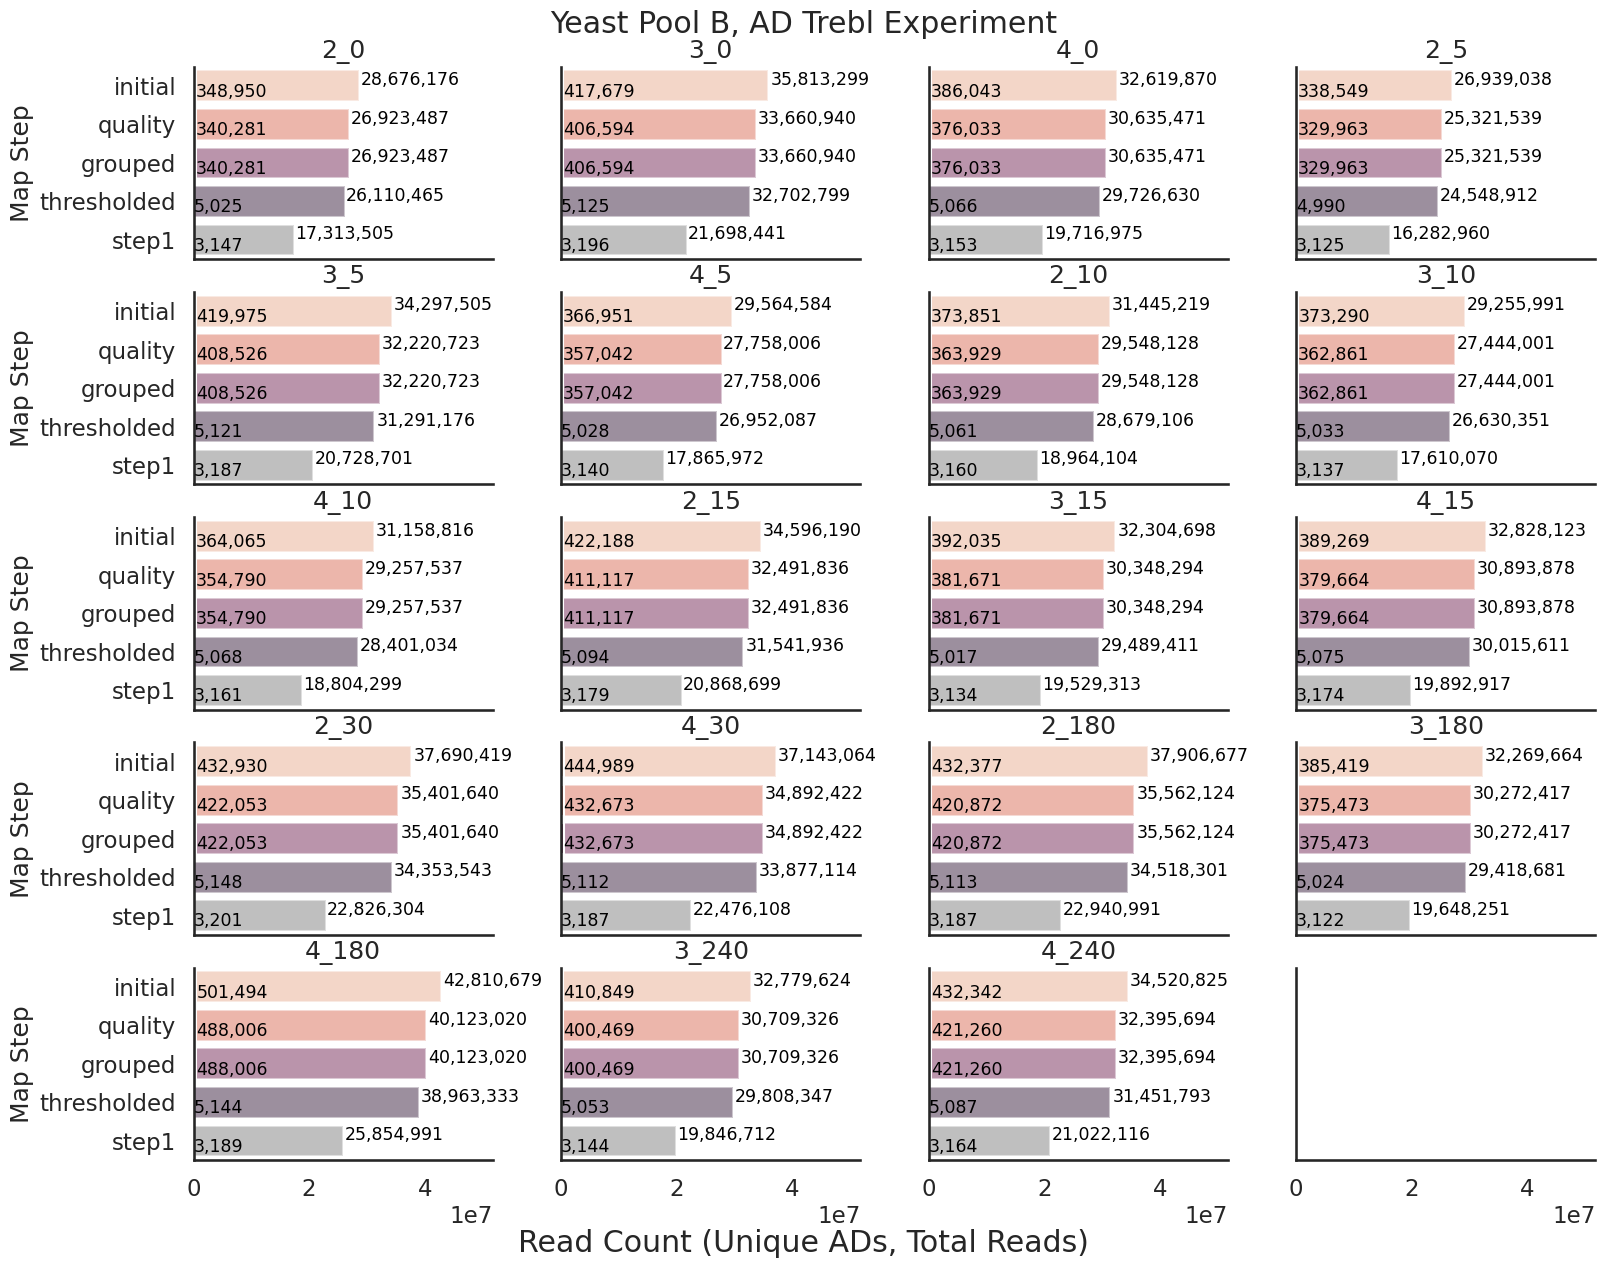

In [13]:
fig, axs = plt.subplots(5,4, sharey = True, sharex = True, figsize = (16,12))
axs = axs.flatten()

i = 0
for table in tqdm.tqdm(AD_prefixes_df["id"]):
    df = AD_loss_table_dict[table]
    df = df.drop(columns = "unique_count")
    df = df.rename(columns = {"unique_AD_count" : "unique_count"})
    
    plotting.plot_loss_helper(ax = axs[i], 
                                palette = 'rocket_r', 
                                text_offset =-0.15, 
                                show_background = True, 
                                default_map_order = ['initial', 'quality', 'designed', 'grouped', 'thresholded'], 
                                output_figures_path = "../../output/GCN4/figures/trebl_experiment_test",
                                table_prefix_with_descriptor = "test",
                                  df = df, 
                              hide_x = False)
    axs[i].set_title(str(AD_prefixes_df["rep"].iloc[i]) + "_" + str(AD_prefixes_df["time"].iloc[i]))
    i += 1
    

for ax in axs:
    ax.set_xlabel("")

    
plt.tight_layout(pad = 0.25)
fig.supxlabel("Read Count (Unique ADs, Total Reads)", y = -0.02)
plt.suptitle("Yeast Pool B, AD Trebl Experiment", y = 1.02)

100%|██████████| 15/15 [00:13<00:00,  1.13it/s]


Text(0.5, 1.02, 'Yeast Pool B, RT Trebl Experiment')

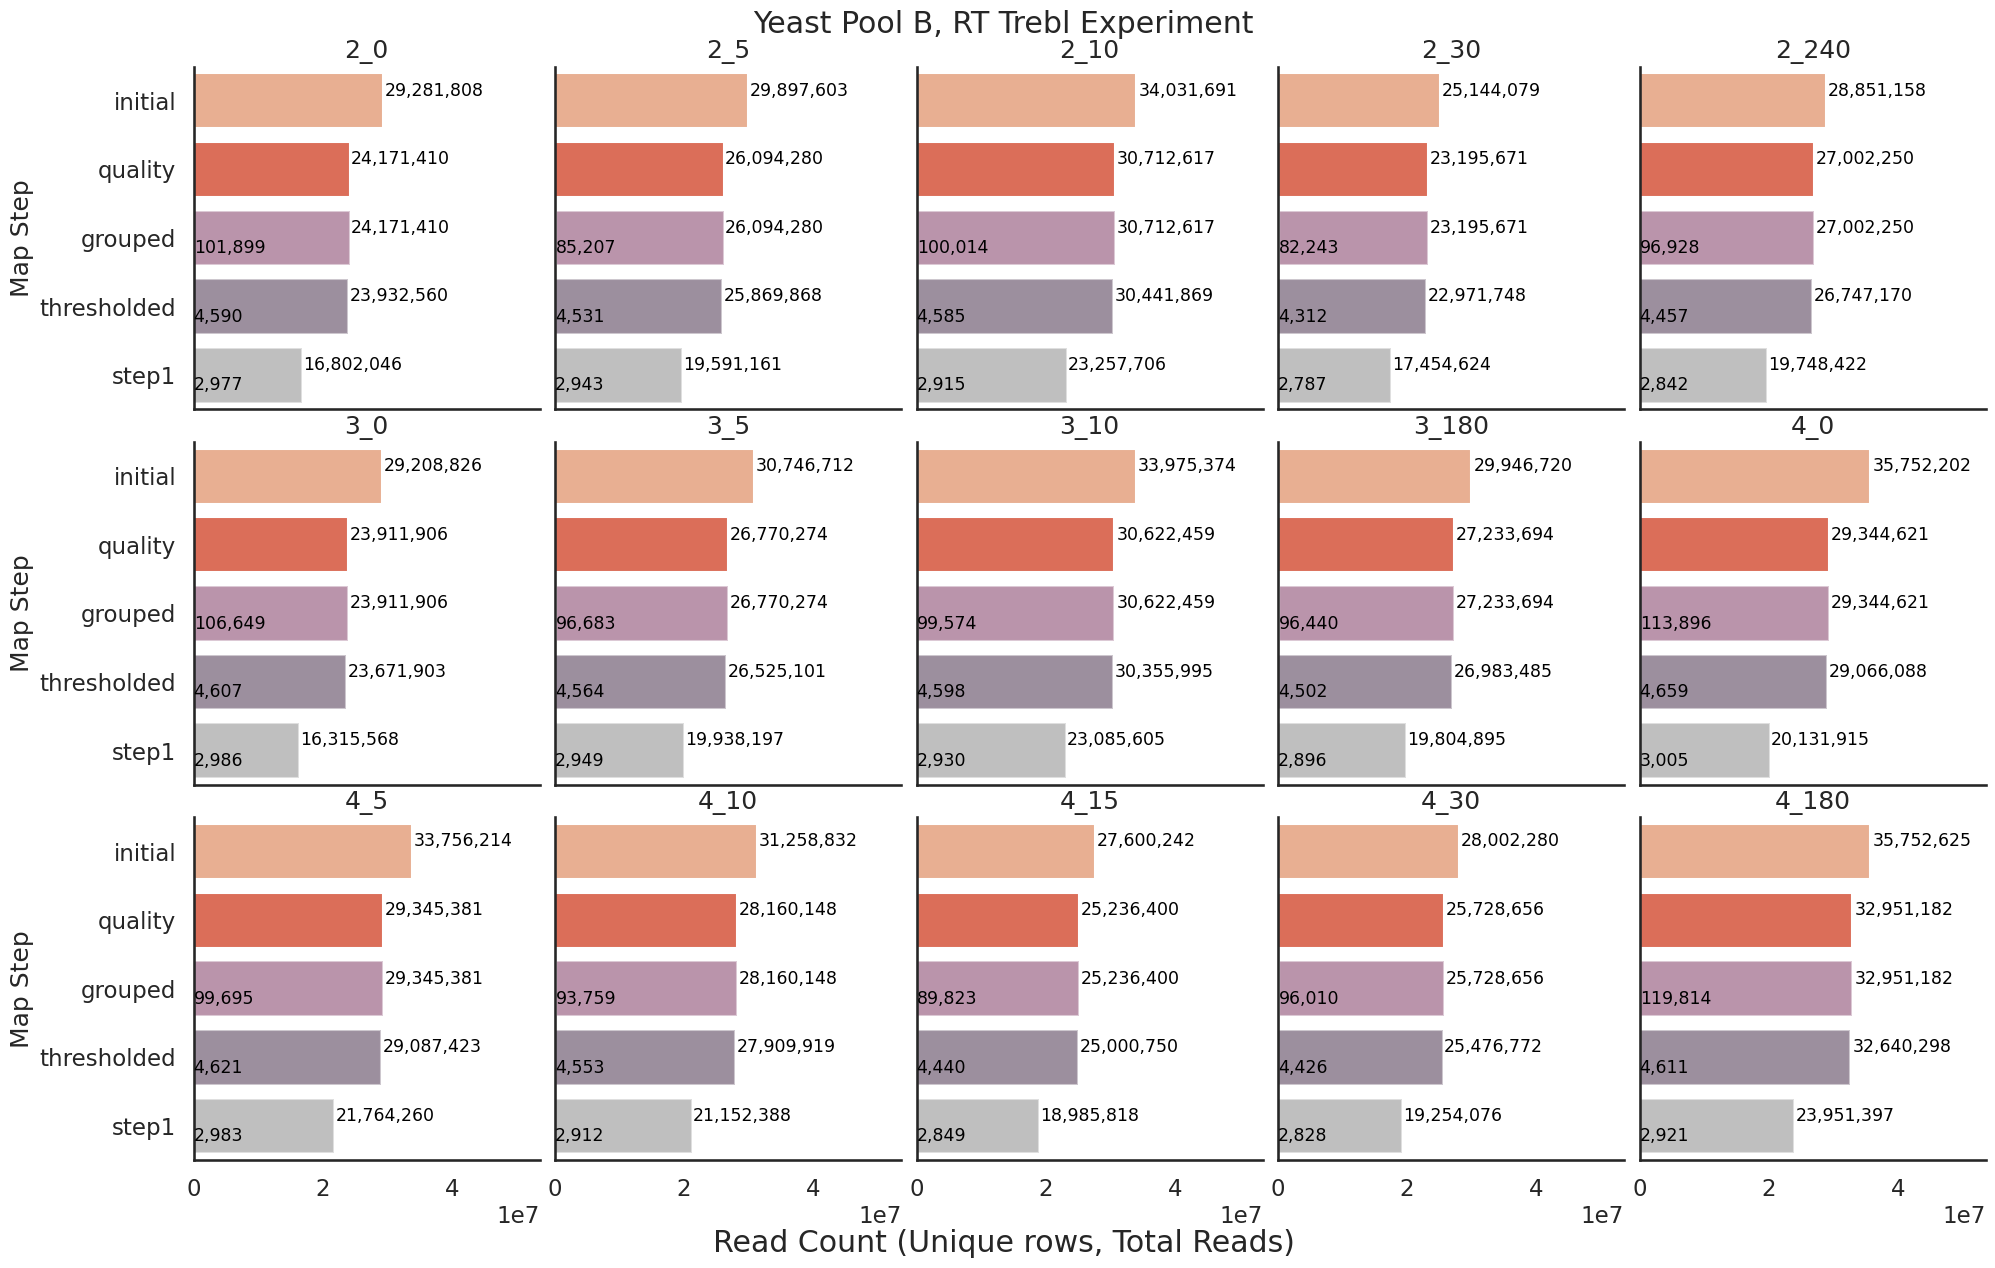

In [11]:
fig, axs = plt.subplots(3,5, sharey = True, sharex = True, figsize = (20,12))
axs = axs.flatten()

i = 0
for table in tqdm.tqdm(RT_prefixes_df["id"]):
    df = RT_loss_table_dict[table]

    plotting.plot_loss_helper(ax = axs[i], 
                                palette = 'rocket_r', 
                                text_offset =-0.15, 
                                show_background = True, 
                                default_map_order = ['initial', 'quality', 'designed', 'grouped', 'thresholded'], 
                                output_figures_path = "../../output/GCN4/figures/trebl_experiment_test",
                                table_prefix_with_descriptor = "test",
                                  df = df, 
                              hide_x = False)
    axs[i].set_title(str(RT_prefixes_df["rep"].iloc[i]) + "_" + str(RT_prefixes_df["time"].iloc[i]))
    i += 1
    

for ax in axs:
    ax.set_xlabel("")

    
plt.tight_layout(pad = 0.25)
fig.supxlabel("Read Count (Unique rows, Total Reads)", y = -0.02)
plt.suptitle("Yeast Pool B, RT Trebl Experiment", y = 1.02)

In [16]:
con.close()